In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_context("notebook")

# **Read data** 

In [17]:
# df = pd.read_csv("data/raw/creditcard.csv")
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

# **Basic Dataset Information**

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [19]:
df.shape

(284807, 31)

In [20]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# **Class Distribution**

In [21]:
class_counts = df["Class"].value_counts()
class_percent = df["Class"].value_counts(normalize=True) * 100

pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percent
})

,Count,Percentage (%)
Class,,
0,284315,99.827251
1,492,0.172749


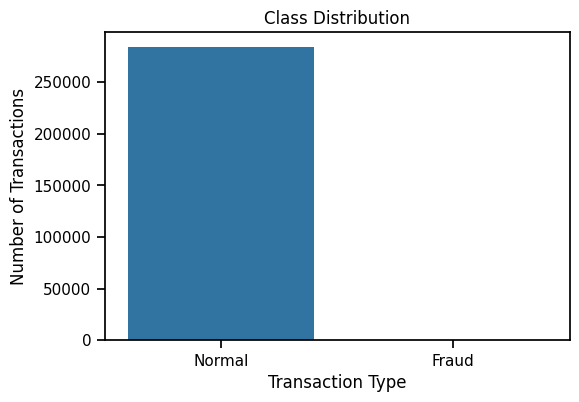

In [24]:
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks([0, 1], ["Normal", "Fraud"])
plt.title("Class Distribution")
plt.ylabel("Number of Transactions")
plt.xlabel("Transaction Type")
plt.show()

# **Transaction Amount Distribution**

In [26]:
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

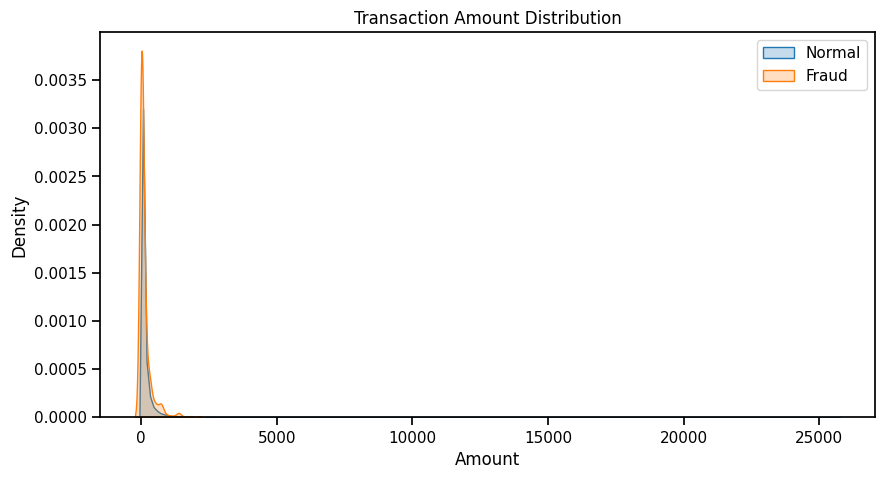

In [27]:
plt.figure(figsize=(10, 5))
sns.kdeplot(normal["Amount"], label="Normal", fill=True)
sns.kdeplot(fraud["Amount"], label="Fraud", fill=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.legend()
plt.show()

# **Correlation Heatmap**

In [28]:
corr = df.corr()

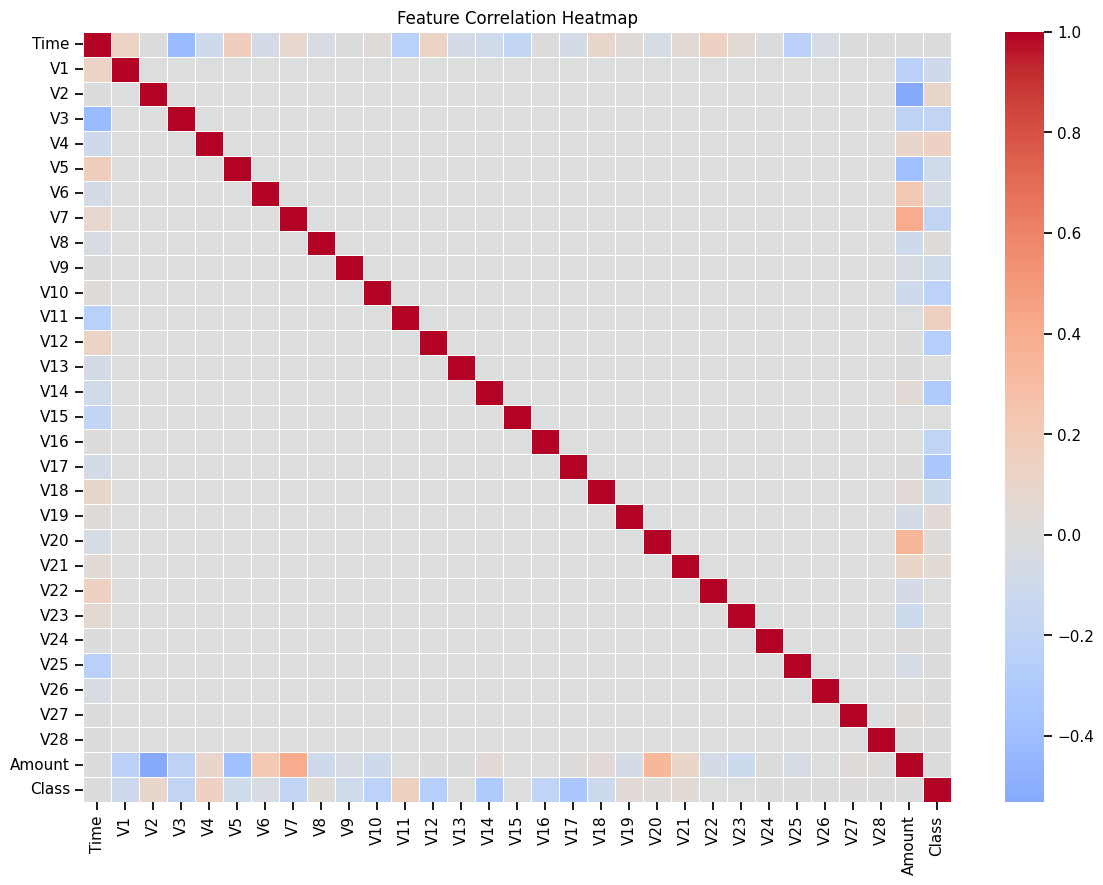

In [29]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()

# **Time-Based Fraud Pattern Analysis**

In [30]:
df["Hour"] = (df["Time"] // 3600) % 24

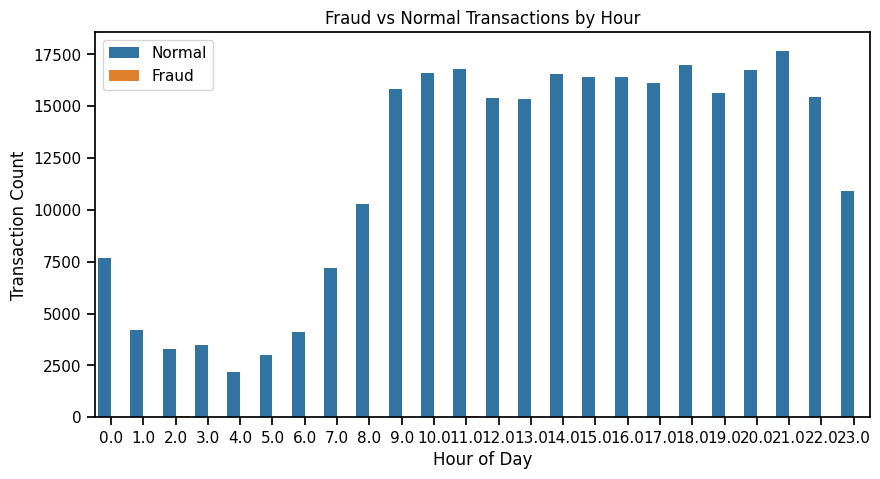

In [31]:
plt.figure(figsize=(10, 5))
sns.countplot(x="Hour", hue="Class", data=df)
plt.title("Fraud vs Normal Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Count")
plt.legend(["Normal", "Fraud"])
plt.show()

# **Top 5 Most Important Features**

In [32]:
top_features = (
    corr["Class"]
    .abs()
    .sort_values(ascending=False)
    .iloc[1:6]
)

top_features

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
Name: Class, dtype: float64

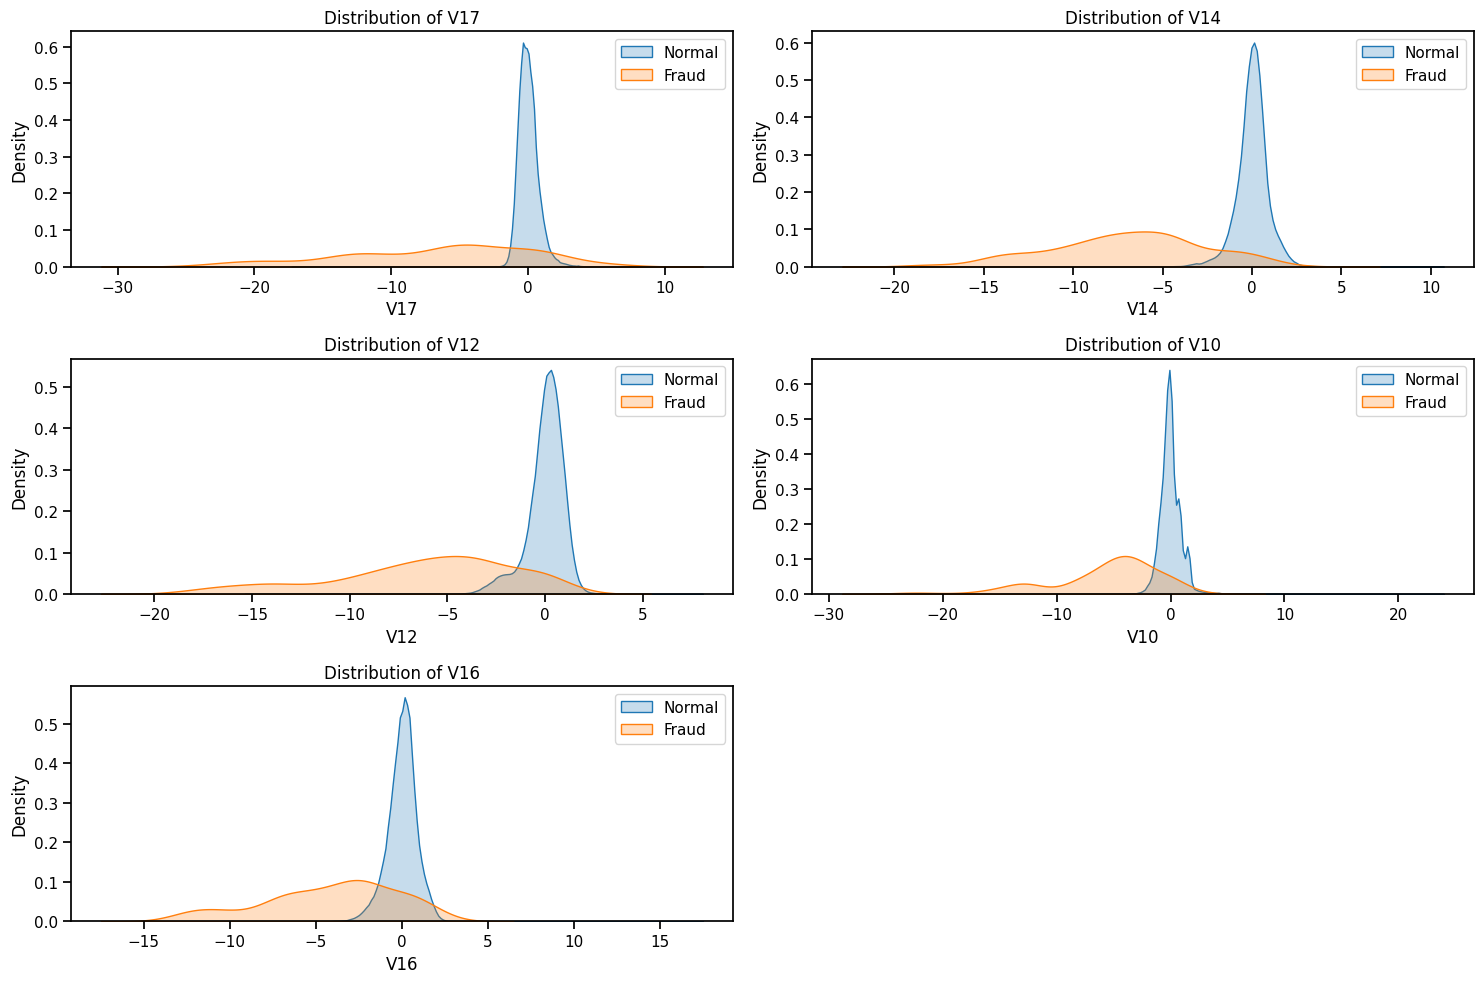

In [33]:
plt.figure(figsize=(15, 10))

for i, feature in enumerate(top_features.index, 1):
    plt.subplot(3, 2, i)
    sns.kdeplot(normal[feature], label="Normal", fill=True)
    sns.kdeplot(fraud[feature], label="Fraud", fill=True)
    plt.title(f"Distribution of {feature}")
    plt.legend()

plt.tight_layout()
plt.show()